In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2

# Set seed for reproducibility
SEED = 28
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
input_shape = (224,224,3)
target_size = list(input_shape)[:2]
batch_size = 32

print('Input Shape', input_shape)
print('Target Size', target_size)
print('Batch Size', batch_size)

Input Shape (224, 224, 3)
Target Size [224, 224]
Batch Size 32


In [3]:
def preprocess(image):
    image = cv2.resize(image,target_size)
    image = tf.keras.applications.densenet.preprocess_input(image)
    return image

In [4]:
datagen = ImageDataGenerator(
    preprocessing_function = preprocess, 
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess,
)

In [5]:
train = datagen.flow_from_directory(
    directory='/kaggle/input/mack-rel/mackerel/train',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = True,
    seed=SEED
)

val = test_datagen.flow_from_directory(
    directory='/kaggle/input/mack-rel/mackerel/val',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed=SEED
)

test = test_datagen.flow_from_directory(
    directory='/kaggle/input/mack-rel/mackerel/test',
    target_size=target_size,
    class_mode='binary',
    batch_size=batch_size,
    shuffle = False,
    seed = SEED
)

Found 13867 images belonging to 2 classes.
Found 4621 images belonging to 2 classes.
Found 4648 images belonging to 2 classes.


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import DenseNet121, DenseNet201, DenseNet169, MobileNetV3Large

def build_model(input_shape=(224, 224, 3), dropout_rate=0.1, l2_lambda=0.001):
    # Initialize L2 regularizer
    l2_reg = regularizers.l2(l2_lambda)
    
    # Load the DenseNet201 model as feature extractor (without the top layers)
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the base model so its weights are not updated during training
    base_model.trainable = False

    # Create the new model on top of the base model
    model = models.Sequential()

    # Add the DenseNet121 as the feature extractor
    model.add(base_model)

    # Add global average pooling
    model.add(layers.GlobalAveragePooling2D())

    # Fully Connected Layers
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=l2_reg))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(256, activation='relu', kernel_regularizer=l2_reg))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))

    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid', kernel_regularizer=l2_reg))

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

In [7]:
model = build_model(input_shape = input_shape)
model.build(input_shape=(None,*input_shape))

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,696,961 (29.36 MB)

 Trainable params: 657,921 (2.51 MB)

 Non-trainable params: 7,039,040 (26.85 MB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the callback
reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,   
    patience=3,           
    min_lr=1e-7,          
    verbose=1,
    mode = 'min'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

In [10]:
callbacks = [early_stopping, reduce_lr_callback]

In [11]:
history = model.fit(train, validation_data=val, epochs=50, batch_size=batch_size, callbacks=callbacks)

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1728469676.800270      87 service.cc:145] XLA service 0x7f4c4c0038e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728469676.800346      87 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  2/434 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.4922 - loss: 2.0355   

I0000 00:00:1728469692.373774      87 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


434/434 ━━━━━━━━━━━━━━━━━━━━ 371s 777ms/step - accuracy: 0.6918 - loss: 1.2928 - val_accuracy: 0.6888 - val_loss: 1.1142 - learning_rate: 0.0010
Epoch 2/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 230s 521ms/step - accuracy: 0.7523 - loss: 0.8691 - val_accuracy: 0.7578 - val_loss: 0.7779 - learning_rate: 0.0010
Epoch 3/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 230s 521ms/step - accuracy: 0.7716 - loss: 0.7194 - val_accuracy: 0.7063 - val_loss: 0.7570 - learning_rate: 0.0010
Epoch 4/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 229s 519ms/step - accuracy: 0.7688 - loss: 0.6415 - val_accuracy: 0.7377 - val_loss: 0.6433 - learning_rate: 0.0010
Epoch 5/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 232s 526ms/step - accuracy: 0.7713 - loss: 0.5908 - val_accuracy: 0.7477 - val_loss: 0.6169 - learning_rate: 0.0010
Epoch 6/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 232s 528ms/step - accuracy: 0.7699 - loss: 0.5654 - val_accuracy: 0.6704 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 7/50
434/434 ━━━━━━━━━━━━━━━━━━━━ 237s 537ms/step - accuracy: 0.7663 

In [12]:
def plot_accuracy_loss(history, label):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Two subplots: one for accuracy, one for loss

    # Plot accuracy on the left
    ax1.plot(history.history['accuracy'], label=f'Train Accuracy {label}')
    ax1.plot(history.history['val_accuracy'], label=f'Val Accuracy {label}')
    ax1.set_title(f'Accuracy {label}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot loss on the right
    ax2.plot(history.history['loss'], label=f'Train Loss {label}')
    ax2.plot(history.history['val_loss'], label=f'Val Loss {label}')
    ax2.set_title(f'Loss {label}')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

<Figure size 1200x600 with 0 Axes>

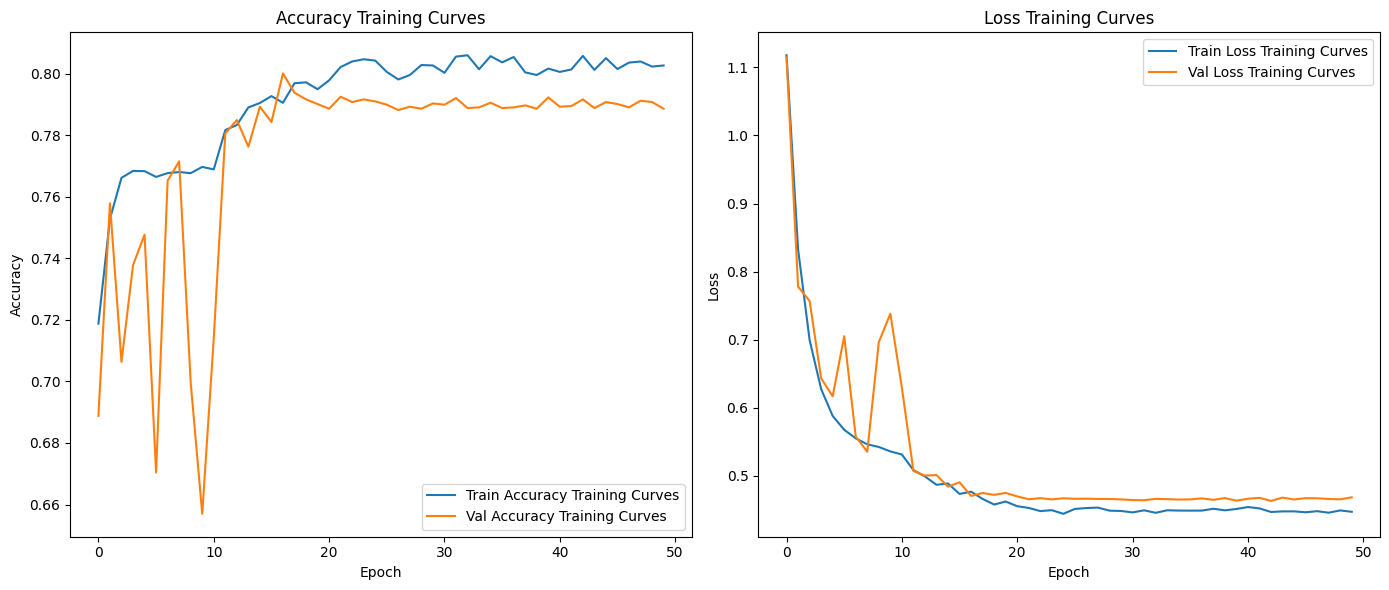

In [13]:
# Plot accuracy and loss for the model without custom callback
plt.figure(figsize=(12, 6))
plot_accuracy_loss(history, label='Training Curves')

In [14]:
from tensorflow.keras.optimizers import Adam

model.layers[0].trainable = True

model.compile(optimizer=Adam(learning_rate = 1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,696,961 (29.36 MB)

 Trainable params: 7,611,777 (29.04 MB)

 Non-trainable params: 85,184 (332.75 KB)

In [15]:
history = model.fit(train, validation_data=val, epochs=20, batch_size=batch_size, callbacks=callbacks)

Epoch 1/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 493s 787ms/step - accuracy: 0.7571 - loss: 0.5161 - val_accuracy: 0.8026 - val_loss: 0.4503 - learning_rate: 1.0000e-05
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 234s 530ms/step - accuracy: 0.8044 - loss: 0.4420 - val_accuracy: 0.8072 - val_loss: 0.4304 - learning_rate: 1.0000e-05
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 234s 532ms/step - accuracy: 0.8208 - loss: 0.4172 - val_accuracy: 0.8238 - val_loss: 0.4039 - learning_rate: 1.0000e-05
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 264s 536ms/step - accuracy: 0.8314 - loss: 0.3970 - val_accuracy: 0.8271 - val_loss: 0.3946 - learning_rate: 1.0000e-05
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 237s 539ms/step - accuracy: 0.8440 - loss: 0.3738 - val_accuracy: 0.8316 - val_loss: 0.3892 - learning_rate: 1.0000e-05
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 238s 539ms/step - accuracy: 0.8506 - loss: 0.3599 - val_accuracy: 0.8407 - val_loss: 0.3763 - learning_rate: 1.0000e-05
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 

<Figure size 1200x600 with 0 Axes>

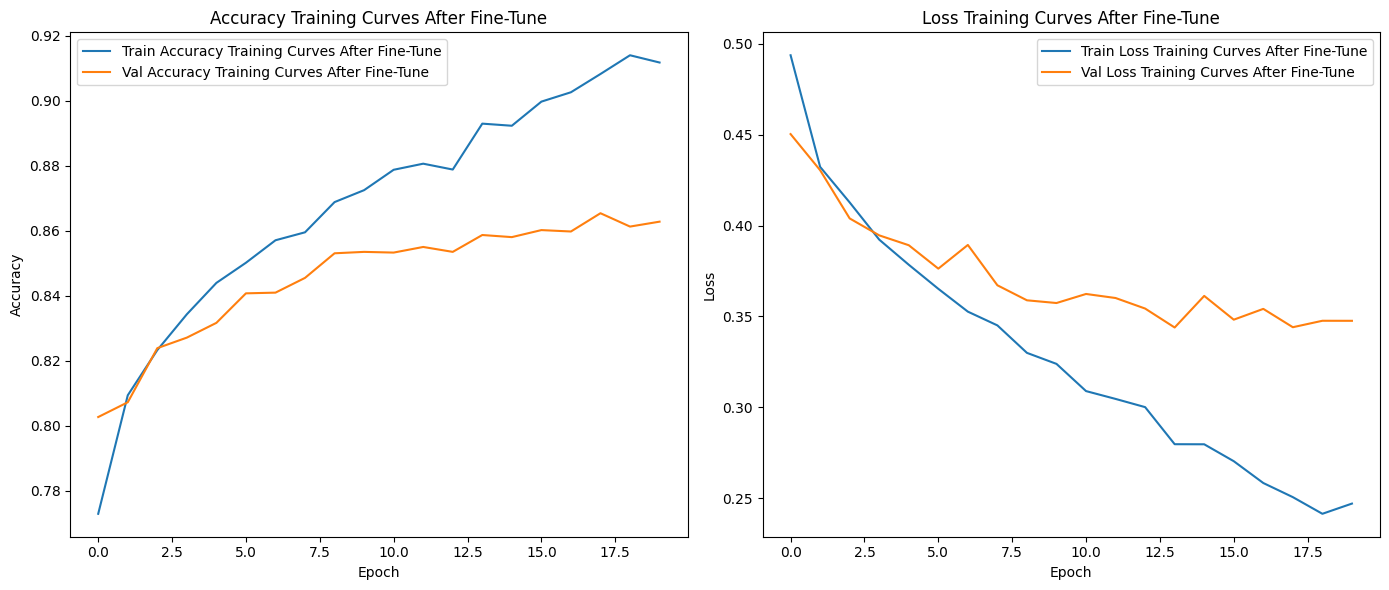

In [16]:
# Plot accuracy and loss for the model without custom callback
plt.figure(figsize=(12, 6))
plot_accuracy_loss(history, label='Training Curves After Fine-Tune')

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

def evaluate_binary_classification_model(model, test_generator, threshold=0.5):
    y_true = test_generator.classes
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred_labels = (y_pred_prob > threshold).astype(int)

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred_labels, target_names=test_generator.class_indices.keys()))

    # Plot confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred_labels)
    plot_confusion_matrix(cnf_matrix, classes=test_generator.class_indices.keys())

145/145 ━━━━━━━━━━━━━━━━━━━━ 40s 209ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.85      0.79      0.82      1853
        good       0.87      0.90      0.88      2768

    accuracy                           0.86      4621
   macro avg       0.86      0.85      0.85      4621
weighted avg       0.86      0.86      0.86      4621

Confusion matrix, without normalization


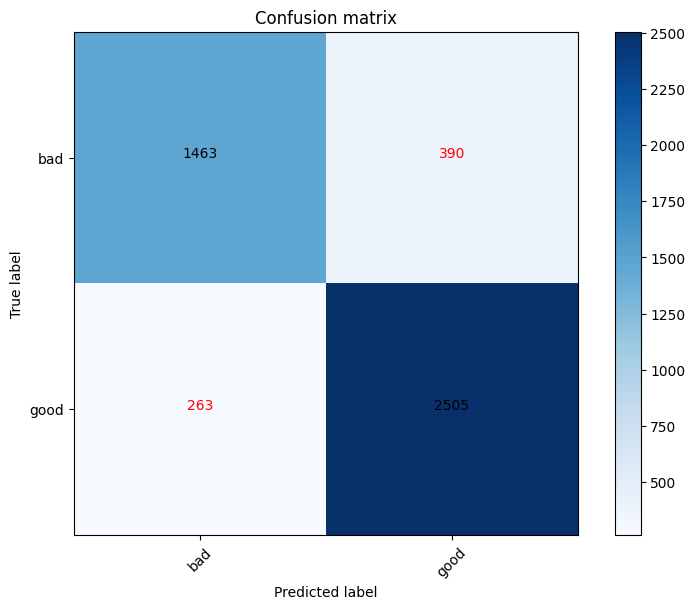

In [18]:
evaluate_binary_classification_model(model,val,0.5 )

  1/146 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


146/146 ━━━━━━━━━━━━━━━━━━━━ 58s 399ms/step
Classification Report:

              precision    recall  f1-score   support

         bad       0.83      0.78      0.80      1865
        good       0.86      0.89      0.87      2783

    accuracy                           0.85      4648
   macro avg       0.84      0.83      0.84      4648
weighted avg       0.85      0.85      0.84      4648

Confusion matrix, without normalization


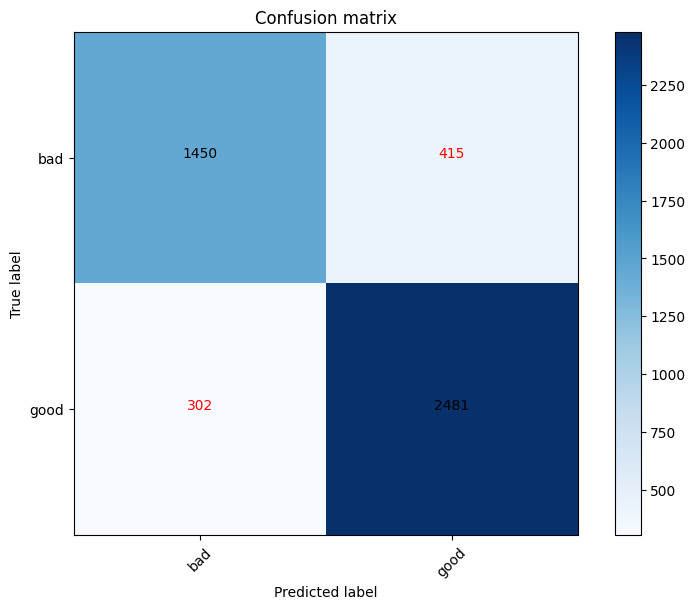

In [19]:
evaluate_binary_classification_model(model,test,0.5 )

In [20]:
model.export('mackerel_model', format='tf')

Saved artifact at 'mackerel_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_427')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139971871836992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614965840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614968656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614966544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614966016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967834816576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967834817280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614975344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967614975520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967834822032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139967834817